In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
amazon_data = pd.read_csv("./dataset/portfolio_data.csv")

In [3]:
amazon_data = amazon_data.drop(["DPZ", "BTC", "NFLX"], axis=1)

In [4]:
amazon_data.head()

,Date,AMZN
0,5/1/2013,248.229996
1,5/2/2013,252.550003
2,5/3/2013,258.049988
3,5/6/2013,255.720001
4,5/7/2013,257.730011


In [5]:
amazon_data.shape

(1520, 2)

In [6]:
amazon_data.info()

<class 'pandas.DataFrame'>
RangeIndex: 1520 entries, 0 to 1519
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Date    1520 non-null   str    
 1   AMZN    1520 non-null   float64
dtypes: float64(1), str(1)
memory usage: 23.9 KB


In [7]:
amazon_data.isnull().sum()

Date    0
AMZN    0
dtype: int64

In [8]:
amazon_data.duplicated().sum()

np.int64(0)

In [9]:
amazon_data["Date"] = pd.to_datetime(amazon_data["Date"])

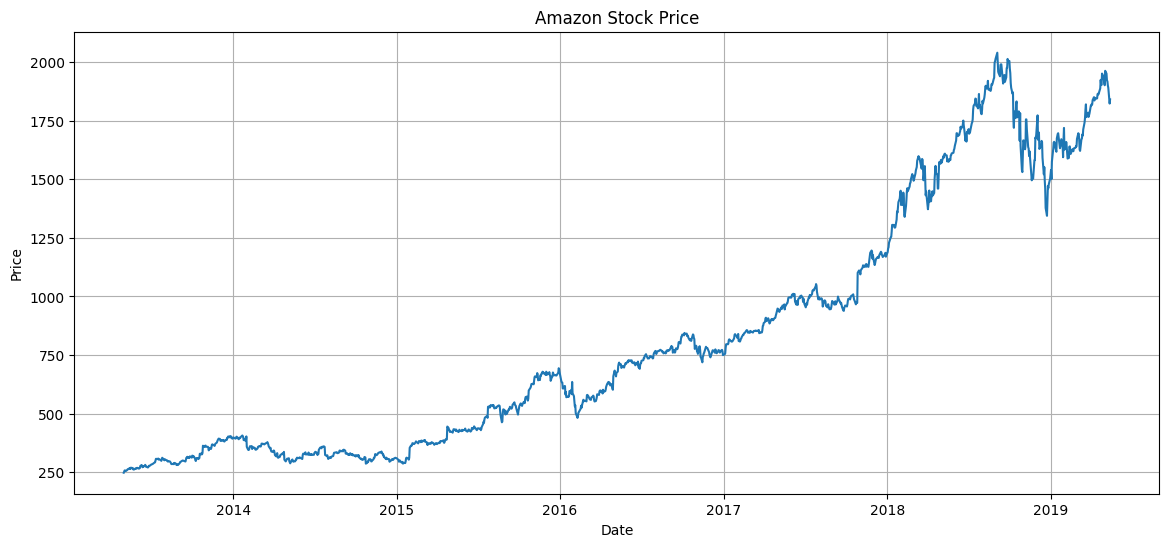

In [10]:
plt.figure(figsize=(14, 6))
plt.plot(amazon_data["Date"], amazon_data["AMZN"])
plt.title("Amazon Stock Price")
plt.xlabel("Date")
plt.ylabel("Price")
plt.grid()
plt.show()

##### input: N days that we already know the values
##### output: y days that we want to predict

In [11]:
amazon_price = amazon_data["AMZN"].values
print(type(amazon_price))

X = []
y = []
input_days = 30
output_days = 1
print(f"Expected generated data length should be: {len(amazon_price) - input_days - output_days + 1}")

counter = 0
for index in range(len(amazon_price) - input_days - output_days + 1):
    x_start_index = index
    x_end_index = index + input_days

    X.append(amazon_price[x_start_index : x_end_index])
    y.append(amazon_price[x_end_index])

    counter += 1
    if counter < 10:
        print(f"x_start_index: {x_start_index} - x_end_index: {x_end_index - output_days} - y_index: {x_end_index}")

<class 'numpy.ndarray'>
Expected generated data length should be: 1490
x_start_index: 0 - x_end_index: 29 - y_index: 30
x_start_index: 1 - x_end_index: 30 - y_index: 31
x_start_index: 2 - x_end_index: 31 - y_index: 32
x_start_index: 3 - x_end_index: 32 - y_index: 33
x_start_index: 4 - x_end_index: 33 - y_index: 34
x_start_index: 5 - x_end_index: 34 - y_index: 35
x_start_index: 6 - x_end_index: 35 - y_index: 36
x_start_index: 7 - x_end_index: 36 - y_index: 37
x_start_index: 8 - x_end_index: 37 - y_index: 38


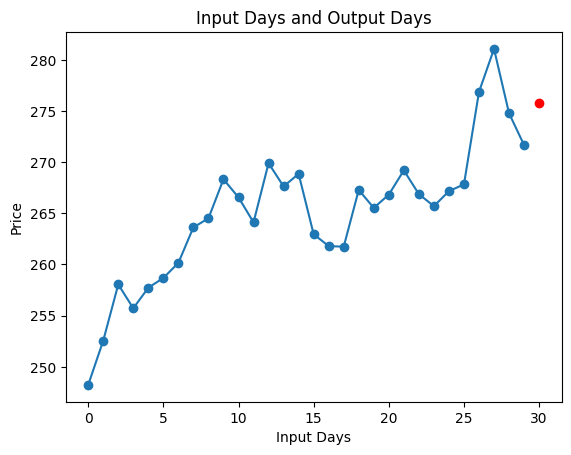

In [12]:
sample_index = 0
plt.plot(X[sample_index], marker= 'o')
plt.plot(input_days, y[sample_index], 'ro')
plt.xlabel("Input Days")
plt.ylabel("Price")
plt.title("Input Days and Output Days")
plt.show()

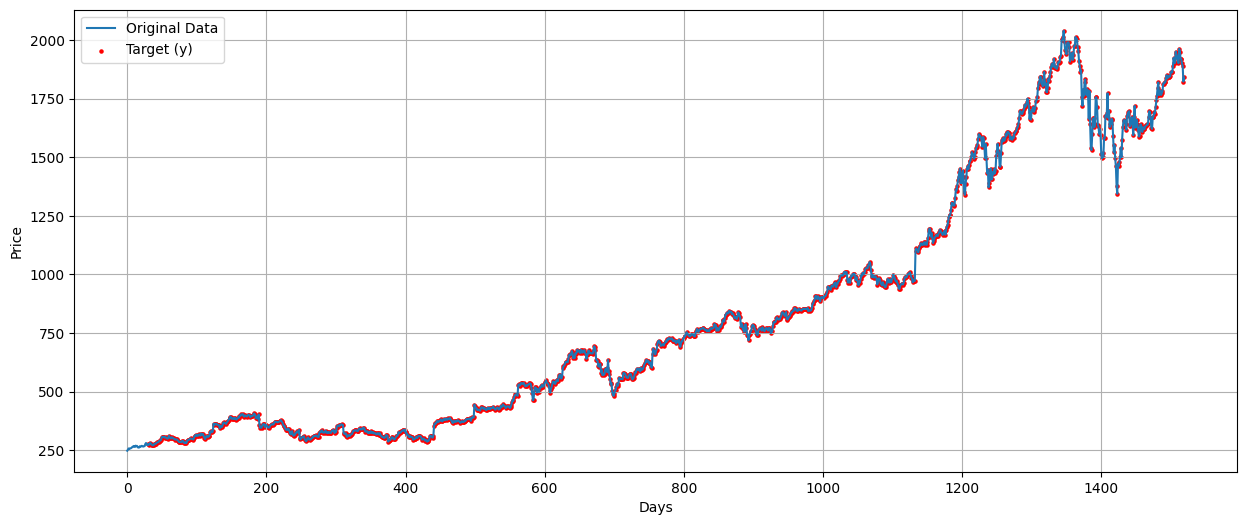

In [ ]:
plt.figure(figsize=(15,6))

plt.plot(amazon_price, label="Original Data")
plt.scatter(range(input_days, len(amazon_price)), y, color="red", s=5, label="Target (y)")
plt.xlabel("Days")
plt.ylabel("Price")
plt.legend()
plt.grid()
plt.show()

### Train & Test split

In [52]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2) #shuffle=

### pre-processing

In [15]:
from sklearn.preprocessing import MinMaxScaler

feature_scaler = MinMaxScaler()
X_train_norm = feature_scaler.fit_transform(X_train)
X_test_norm = feature_scaler.transform(X_test)

target_scaler = MinMaxScaler()
y_train_norm = target_scaler.fit_transform(np.reshape(y_train, (-1, 1)))
y_test_norm = target_scaler.transform(np.reshape(y_test, (-1, 1)))

In [16]:
print(f"Input Days: {input_days} - Output Days: {output_days}")
print(f"X_train Shape: {X_train_norm.shape} - X_test Shape: {X_test_norm.shape}")
print(f"y_train Shape: {y_train_norm.shape} - y_test Shape: {y_test_norm.shape}")

Input Days: 30 - Output Days: 1
X_train Shape: (1192, 30) - X_test Shape: (298, 30)
y_train Shape: (1192, 1) - y_test Shape: (298, 1)


### 1.Linear Regression

In [17]:
from sklearn.linear_model import LinearRegression

linear_model = LinearRegression()
linear_model.fit(X_train_norm, y_train_norm)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [18]:
linear_pred = linear_model.predict(X_test_norm)

In [19]:
print(f"linear Predicted Shape: {linear_pred.shape}")

linear Predicted Shape: (298, 1)


In [20]:
selected_index = 5

selected_x = X_test_norm[selected_index]
selected_y = y_test_norm[selected_index]
selected_pred = linear_pred[selected_index]

print(f"Selected X: {selected_x}")
print(f"Selected y: {selected_y}")
print(f"Selected predict: {selected_pred}")

Selected X: [0.75626369 0.75490779 0.74022166 0.74647802 0.74309398 0.73880718
 0.75609588 0.7535575  0.75382079 0.75450139 0.75848395 0.76001394
 0.76676736 0.76943586 0.77613336 0.78948909 0.80697164 0.80663415
 0.80258517 0.79959187 0.80233883 0.80789374 0.82365734 0.8220497
 0.81745035 0.82179628 0.82772911 0.83637851 0.83771529 0.81692579]
Selected y: [0.78723502]
Selected predict: [0.81576157]


In [21]:
print("Train Linear:", linear_model.score(X_train_norm, y_train_norm))
print("Test Linear:", linear_model.score(X_test_norm, y_test_norm))

Train Linear: 0.998692041731944
Test Linear: 0.9989281555669798


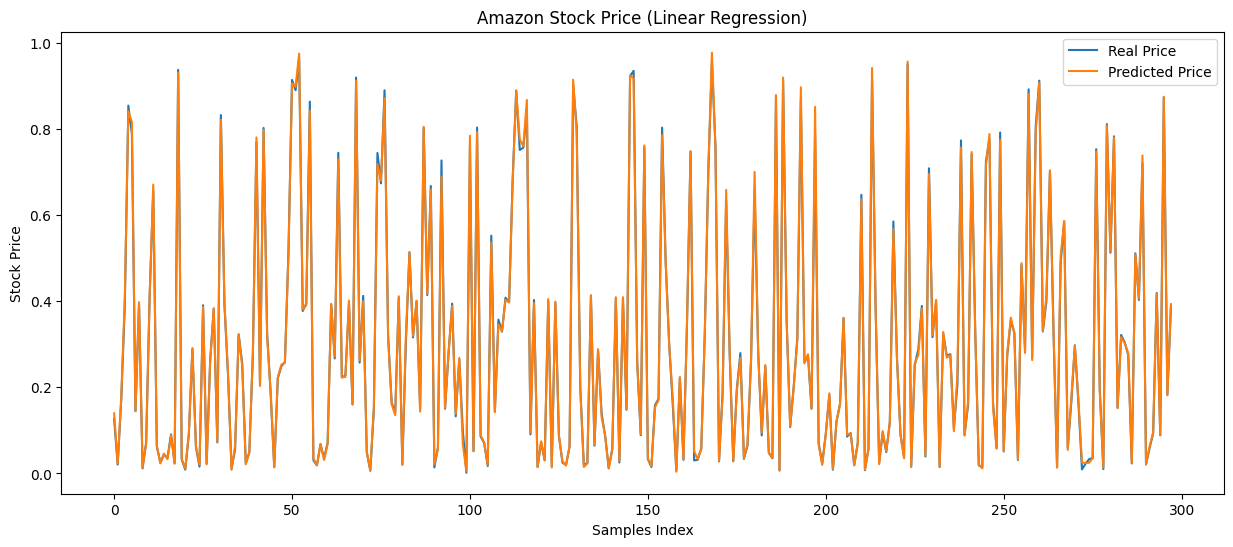

In [22]:
plt.figure(figsize=(15,6))
plt.plot(y_test_norm, label="Real Price")
plt.plot(linear_pred, label="Predicted Price")
plt.title("Amazon Stock Price (Linear Regression)")
plt.xlabel("Samples Index")
plt.ylabel("Stock Price")
plt.legend(loc='upper right')
plt.show()

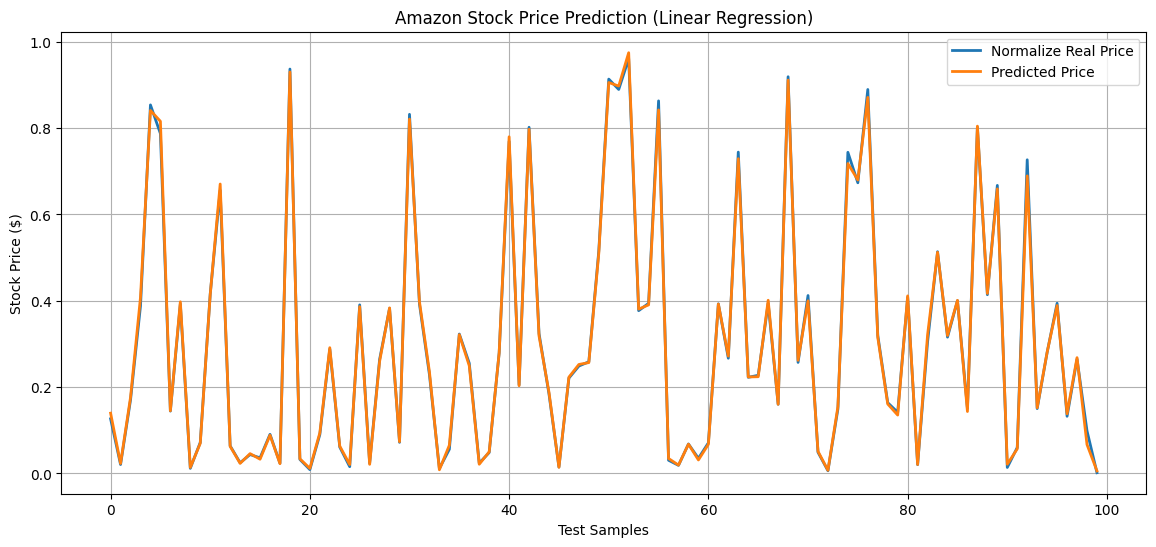

In [23]:
# Plot only the first 100 samples
plt.figure(figsize=(14,6))
plt.plot(y_test_norm[:100], label="Normalize Real Price", linewidth=2)
plt.plot(linear_pred[:100], label="Predicted Price", linewidth=2)
plt.title("Amazon Stock Price Prediction (Linear Regression)")
plt.xlabel("Test Samples")
plt.ylabel("Stock Price ($)")
plt.legend()
plt.grid(True)
plt.show()

### 2.Support Vector Regression

In [24]:
from sklearn.svm import SVR

svr_model = SVR(C=100, kernel="linear") #epsilon=1, gamma="scale"
svr_model.fit(X_train_norm, y_train_norm)

e:\Python Git\ML\breast_cancer_classification\.venv\Lib\site-packages\sklearn\utils\validation.py:1352: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm.If none is given, 'rbf' will be used. If a callable is given it isused to precompute the kernel matrix.For an intuitive visualization of different kernel typessee :ref:`sphx_glr_auto_examples_svm_plot_svm_regression.py`",'linear'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive.The penalty is a squared l2. For an intuitive visualization of theeffects of scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",100
,"epsilon epsilon: float, default=0.1Epsilon in the epsilon-SVR model. It specifies the epsilon-tubewithin which no penalty is associated in the training loss functionwith points predicted within a distance epsilon from the actualvalue. Must be non-negative.",0.1
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False
,"max_iter max_iter: int, default=-1Hard limit on iterations within solver, or -1 for no limit.",-1


In [25]:
svr_pred = svr_model.predict(X_test_norm)

In [26]:
print("Train SVR:", svr_model.score(X_train_norm, y_train_norm))
print("Test SVR:", svr_model.score(X_test_norm, y_test_norm))

Train SVR: 0.9724946870742966
Test SVR: 0.9712854515831012


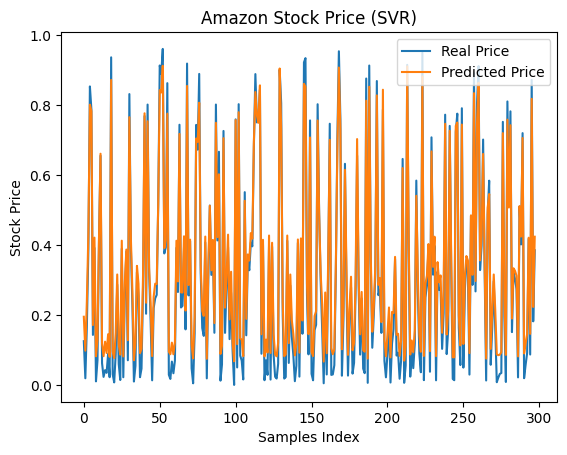

In [27]:
plt.plot(y_test_norm, label="Real Price")
plt.plot(svr_pred, label="Predicted Price")
plt.title("Amazon Stock Price (SVR)")
plt.xlabel("Samples Index")
plt.ylabel("Stock Price")
plt.legend(loc='upper right')
plt.show()

### 3.Random Forest Regressor

In [ ]:
from sklearn.ensemble import RandomForestRegressor

rf_model = RandomForestRegressor(n_estimators=200, max_depth=8, min_samples_leaf=5)
rf_model.fit(X_train_norm, y_train_norm)

e:\Python Git\ML\breast_cancer_classification\.venv\Lib\site-packages\sklearn\base.py:1336: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",200
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",8
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples a

In [29]:
rf_pred = rf_model.predict(X_test_norm)

In [30]:
print("Train RF:", rf_model.score(X_train_norm, y_train_norm))
print("Test RF:", rf_model.score(X_test_norm, y_test_norm))

Train RF: 0.9993056411305716
Test RF: 0.9987466625967644


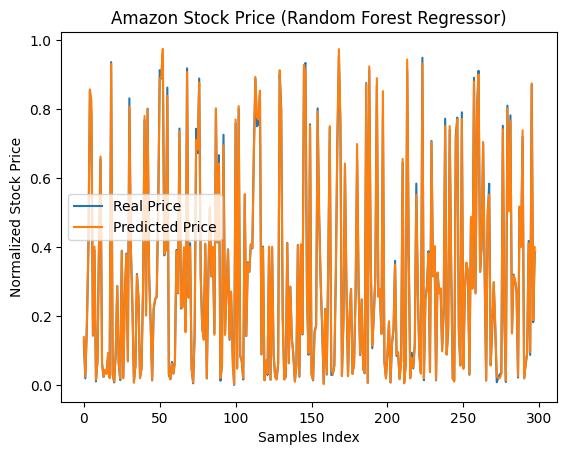

In [31]:
plt.plot(y_test_norm, label="Real Price")
plt.plot(rf_pred, label="Predicted Price")
plt.title("Amazon Stock Price (Random Forest Regressor)")
plt.xlabel("Samples Index")
plt.ylabel("Normalized Stock Price")
plt.legend()
plt.show()

### 4.Decision Tree Regressor

In [32]:
from sklearn.tree import DecisionTreeRegressor

dt_model = DecisionTreeRegressor(max_depth=5, min_samples_split=20, min_samples_leaf=10)
dt_model.fit(X_train_norm, y_train_norm)

,"criterion criterion: {""squared_error"", ""friedman_mse"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in the half mean Poisson deviance to find splits... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 0.24 Poisson deviance criterion.",'squared_error'
,"splitter splitter: {""best"", ""random""}, default=""best""The strategy used to choose the split at each node. Supportedstrategies are ""best"" to choose the best split and ""random"" to choosethe best random split.",'best'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.For an example of how ``max_depth`` influences the model, see:ref:`sphx_glr_auto_examples_tree_plot_tree_regression.py`.",5
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",20
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",10
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: int, float or {""sqrt"", ""log2""}, default=NoneThe number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",None
,"random_state random_state: int, RandomState instance or None, default=NoneControls the randomness of the estimator. The features are alwaysrandomly permuted at each split, even if ``splitter`` is set to``""best""``. When ``max_features < n_features``, the algorithm willselect ``max_features`` at random at each split before finding the bestsplit among them. But the best found split may vary across differentruns, even if ``max_features=n_features``. That is the case, if theimprovement of the criterion is identical for several splits and onesplit has to be selected at random. To obtain a deterministic behaviourduring fitting, ``random_state`` has to be fixed to an integer.See :term:`Glossary ` for details.",None
,"max_

In [33]:
dt_pred = dt_model.predict(X_test_norm)

In [34]:
print("Train DT:", dt_model.score(X_train_norm, y_train_norm))
print("Test DT:", dt_model.score(X_test_norm, y_test_norm))

Train DT: 0.9982382133815401
Test DT: 0.9978791133005332


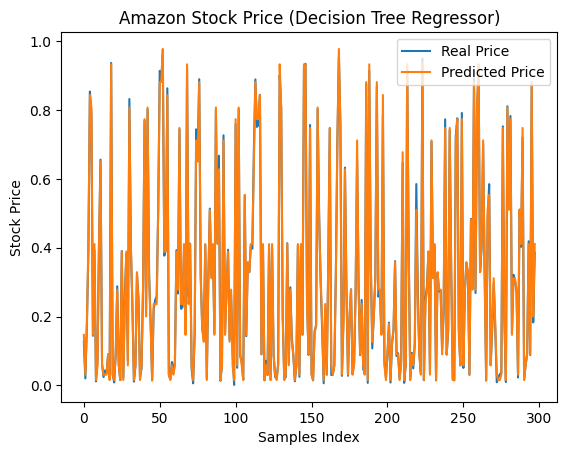

In [35]:
plt.plot(y_test_norm, label="Real Price")
plt.plot(dt_pred, label="Predicted Price")
plt.title("Amazon Stock Price (Decision Tree Regressor)")
plt.xlabel("Samples Index")
plt.ylabel("Stock Price")
plt.legend(loc='upper right')
plt.show()

### 5.K-Neighbors Regressor

In [36]:
from sklearn.neighbors import KNeighborsRegressor

knn_model = KNeighborsRegressor()
knn_model.fit(X_train_norm, y_train_norm)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Uniform weights are used by default.See the following example for a demonstration of the impact ofdifferent weighting schemes on predictions::ref:`sphx_glr_auto_examples_neighbors_plot_regression.py`.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this isequivalent to using manhattan_distance (l1), and euclidean_distance(l2) for p = 2. For arbitrary p, minkowski_distance (l_p) is used.",2
,"metric metric: str, DistanceMetric object or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.If metric is a DistanceMetric object, it will be passed directly tothe underlying computation routines.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details.Doesn't affect :meth:`fit` method.",None


In [37]:
knn_pred = knn_model.predict(X_test_norm)

In [38]:
print("Train KNN:", knn_model.score(X_train_norm, y_train_norm))
print("Test KNN:", knn_model.score(X_test_norm, y_test_norm))

Train KNN: 0.999077583172867
Test KNN: 0.9991039004142134


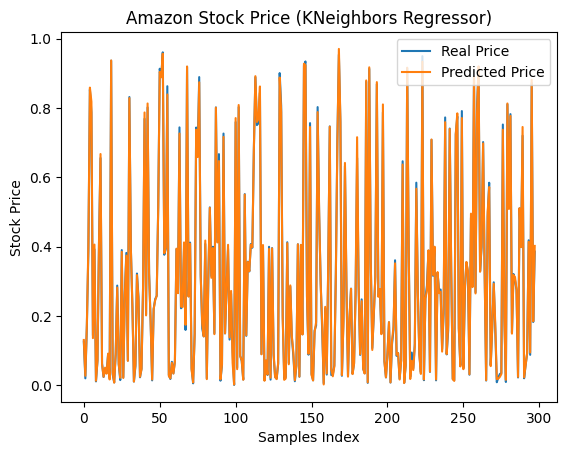

In [39]:
plt.plot(y_test_norm, label="Real Price")
plt.plot(knn_pred, label="Predicted Price")
plt.title("Amazon Stock Price (KNeighbors Regressor)")
plt.xlabel("Samples Index")
plt.ylabel("Stock Price")
plt.legend(loc='upper right')
plt.show()

### 6.MLP Regression(ANN)

In [40]:
from sklearn.neural_network import MLPRegressor
mlp_model = MLPRegressor()
mlp_model.fit(X_train_norm, y_train_norm)

e:\Python Git\ML\breast_cancer_classification\.venv\Lib\site-packages\sklearn\neural_network\_multilayer_perceptron.py:1775: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples, ), for example using ravel().
  y = column_or_1d(y, warn=True)


,"loss loss: {'squared_error', 'poisson'}, default='squared_error'The loss function to use when training the weights. Note that the""squared error"" and ""poisson"" losses actually implement""half squares error"" and ""half poisson deviance"" to simplify thecomputation of the gradient. Furthermore, the ""poisson"" loss internally usesa log-link (exponential as the output activation function) and requires``y >= 0``... versionchanged:: 1.7 Added parameter `loss` and option 'poisson'.",'squared_error'
,"hidden_layer_sizes hidden_layer_sizes: array-like of shape(n_layers - 2,), default=(100,)The ith element represents the number of neurons in the ithhidden layer.","(100,)"
,"activation activation: {'identity', 'logistic', 'tanh', 'relu'}, default='relu'Activation function for the hidden layer.- 'identity', no-op activation, useful to implement linear bottleneck, returns f(x) = x- 'logistic', the logistic sigmoid function, returns f(x) = 1 / (1 + exp(-x)).- 'tanh', the hyperbolic tan function, returns f(x) = tanh(x).- 'relu', the rectified linear unit function, returns f(x) = max(0, x)",'relu'
,"solver solver: {'lbfgs', 'sgd', 'adam'}, default='adam'The solver for weight optimization.- 'lbfgs' is an optimizer in the family of quasi-Newton methods.- 'sgd' refers to stochastic gradient descent.- 'adam' refers to a stochastic gradient-based optimizer proposed by Kingma, Diederik, and Jimmy BaFor a comparison between Adam optimizer and SGD, see:ref:`sphx_glr_auto_examples_neural_networks_plot_mlp_training_curves.py`.Note: The default solver 'adam' works pretty well on relativelylarge datasets (with thousands of training samples or more) in terms ofboth training time and validation score.For small datasets, however, 'lbfgs' can converge faster and performbetter.",'adam'
,"alpha alpha: float, default=0.0001Strength of the L2 regularization term. The L2 regularization termis divided by the sample size when added to the loss.",0.0001
,"batch_size batch_size: int, default='auto'Size of minibatches for stochastic optimizers.If the solver is 'lbfgs', the regressor will not use minibatch.When set to ""auto"", `batch_size=min(200, n_samples)`.",'auto'
,"learning_rate learning_rate: {'constant', 'invscaling', 'adaptive'}, default='constant'Learning rate schedule for weight updates.- 'constant' is a constant learning rate given by 'learning_rate_init'.- 'invscaling' gradually decreases the learning rate ``learning_rate_`` at each time step 't' using an inverse scaling exponent of 'power_t'. effective_learning_rate = learning_rate_init / pow(t, power_t)- 'adaptive' keeps the learning rate constant to 'learning_rate_init' as long as training loss keeps decreasing. Each time two consecutive epochs fail to decrease training loss by at least tol, or fail to increase validation score by at least tol if 'early_stopping' is on, the current learning rate is divided by 5.Only used when solver='sgd'.",'constant'
,"learning_rate_init learning_rate_init: float, default=0.001The initial learning rate used. It controls the step-sizein updating the weights. Only used when solver='sgd' or 'adam'.",0.001
,"power_t power_t: float, default=0.5The exponent for inverse scaling learning rate.It is used in updating effective learning rate when the learning_rateis set to 'invscaling'. Only used when solver='sgd'.",0.5
,"max_iter max_iter: int, default=200Maximum number of iterations. The solver iterates until convergence(determined by 'tol') or this number of iterations. For stochasticsolvers ('sgd', 'adam'), note that this determines the number of epochs(how many times each data point will be used), not the number ofgradient steps.",200
,"shuffle shuffle: bool, default=TrueWhether to shuffle samples in each iteration. Only used whensolver='sgd' or 'adam'.",True


In [41]:
mlp_pred = mlp_model.predict(X_test_norm)

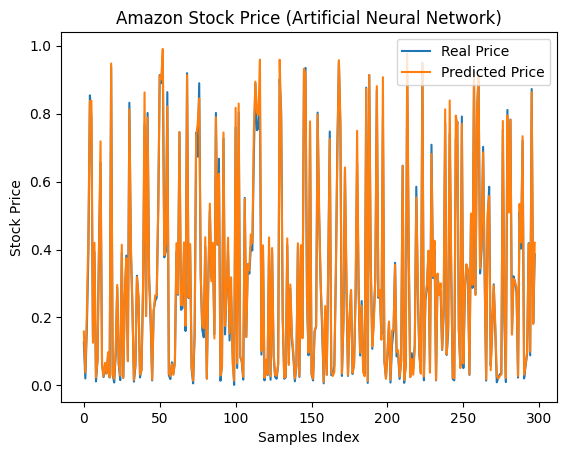

In [42]:
plt.plot(y_test_norm, label="Real Price")
plt.plot(mlp_pred, label="Predicted Price")
plt.title("Amazon Stock Price (Artificial Neural Network)")
plt.xlabel("Samples Index")
plt.ylabel("Stock Price")
plt.legend(loc='upper right')
plt.show()

### Comparison of Regression Models

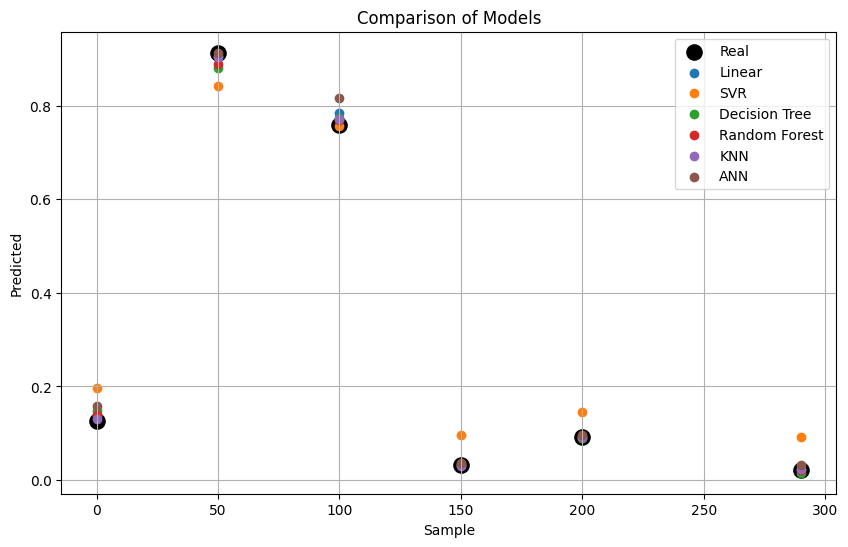

In [43]:
samples = [0, 50, 100, 200, 150, 290]
plt.figure(figsize=(10,6))
plt.scatter(samples, y_test_norm[samples], label="Real", s=120, color= 'black')

plt.scatter(samples, linear_pred[samples], label="Linear")
plt.scatter(samples, svr_pred[samples], label="SVR")
plt.scatter(samples, dt_pred[samples], label="Decision Tree")
plt.scatter(samples, rf_pred[samples], label="Random Forest")
plt.scatter(samples, knn_pred[samples], label="KNN")
plt.scatter(samples, mlp_pred[samples], label="ANN")
plt.legend()
plt.grid()
plt.xlabel("Sample")
plt.ylabel("Predicted")
plt.title("Comparison of Models")
plt.show()

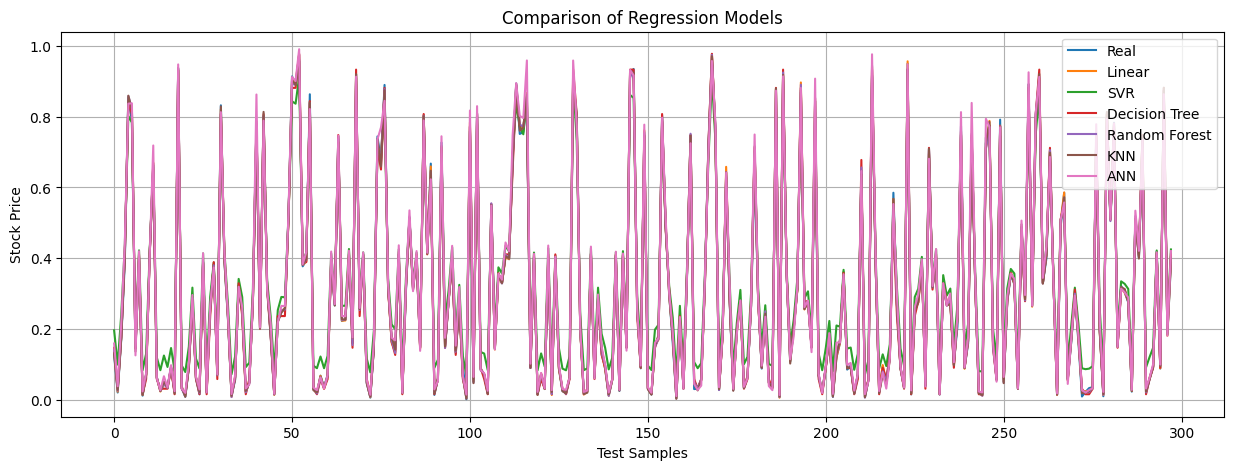

In [45]:
plt.figure(figsize=(15,5))
plt.plot(y_test_norm, label="Real")
plt.plot(linear_pred, label="Linear")
plt.plot(svr_pred, label="SVR")
plt.plot(dt_pred, label="Decision Tree")
plt.plot(rf_pred, label="Random Forest")
plt.plot(knn_pred, label="KNN")
plt.plot(mlp_pred, label="ANN")
plt.title("Comparison of Regression Models")
plt.xlabel("Test Samples")
plt.ylabel("Stock Price")
plt.legend()
plt.grid()
plt.show()

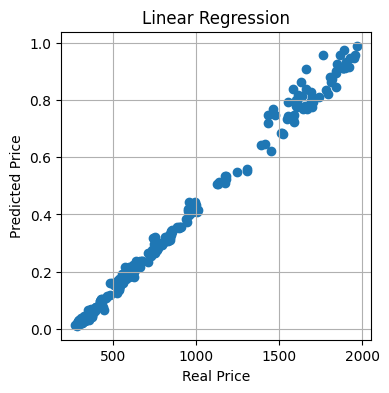

In [46]:
regression_models = mlp_pred

plt.figure(figsize=(4,4))
plt.scatter(y_test, regression_models)
plt.title("Linear Regression")
plt.xlabel("Real Price")
plt.ylabel("Predicted Price")
plt.grid()
plt.show()

### Train and Test Score Comparison

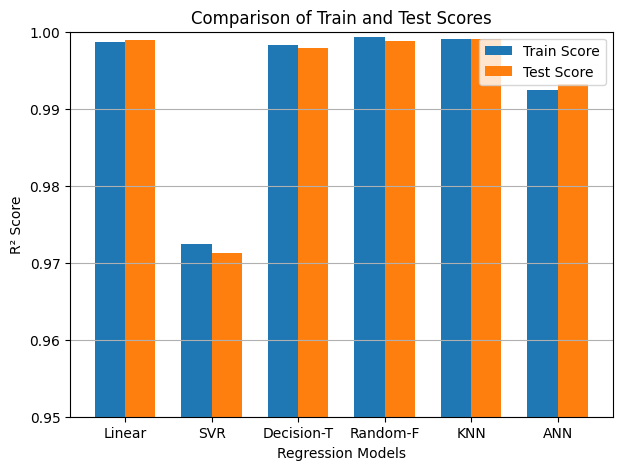

In [47]:
models = ["Linear","SVR","Decision-T","Random-F","KNN","ANN"]

train_scores = [linear_model.score(X_train_norm, y_train_norm),
    svr_model.score(X_train_norm, y_train_norm),
    dt_model.score(X_train_norm, y_train_norm),
    rf_model.score(X_train_norm, y_train_norm),
    knn_model.score(X_train_norm, y_train_norm),
    mlp_model.score(X_train_norm, y_train_norm)]

test_scores = [linear_model.score(X_test_norm, y_test_norm),
    svr_model.score(X_test_norm, y_test_norm),
    dt_model.score(X_test_norm, y_test_norm),
    rf_model.score(X_test_norm, y_test_norm),
    knn_model.score(X_test_norm, y_test_norm),
    mlp_model.score(X_test_norm, y_test_norm)]

x = np.arange(len(models))
width = 0.35
plt.figure(figsize=(7,5))
plt.bar(x - width/2, train_scores, width, label="Train Score")
plt.bar(x + width/2, test_scores, width, label="Test Score")
plt.xticks(x, models)
plt.ylim(0.95, 1.0)
plt.xlabel("Regression Models")
plt.ylabel("R² Score")
plt.title("Comparison of Train and Test Scores")
plt.legend()
plt.grid(axis='y')
plt.show()

#### Mean absolute error - Mean squared error - R2 score

In [48]:
from sklearn.metrics import (mean_absolute_error,mean_squared_error,r2_score)

results = pd.DataFrame({"Model":models,
    "MAE":[
        mean_absolute_error(y_test_norm, linear_pred),
        mean_absolute_error(y_test_norm, svr_pred),
        mean_absolute_error(y_test_norm, dt_pred),
        mean_absolute_error(y_test_norm, rf_pred),
        mean_absolute_error(y_test_norm, knn_pred),
        mean_absolute_error(y_test_norm, mlp_pred)],

    "MSE":[
        mean_squared_error(y_test_norm, linear_pred),
        mean_squared_error(y_test_norm, svr_pred),
        mean_squared_error(y_test_norm, dt_pred),
        mean_squared_error(y_test_norm, rf_pred),
        mean_squared_error(y_test_norm, knn_pred),
        mean_squared_error(y_test_norm, mlp_pred)],

    "RMSE":[
        np.sqrt(mean_squared_error(y_test_norm, linear_pred)),
        np.sqrt(mean_squared_error(y_test_norm, svr_pred)),
        np.sqrt(mean_squared_error(y_test_norm, dt_pred)),
        np.sqrt(mean_squared_error(y_test_norm, rf_pred)),
        np.sqrt(mean_squared_error(y_test_norm, knn_pred)),
        np.sqrt(mean_squared_error(y_test_norm, mlp_pred))],

    "R2":[
        r2_score(y_test_norm, linear_pred),
        r2_score(y_test_norm, svr_pred),
        r2_score(y_test_norm, dt_pred),
        r2_score(y_test_norm, rf_pred),
        r2_score(y_test_norm, knn_pred),
        r2_score(y_test_norm, mlp_pred)]})

print(results.round(4))

        Model     MAE     MSE    RMSE      R2
0      Linear  0.0057  0.0001  0.0094  0.9989
1         SVR  0.0437  0.0023  0.0484  0.9713
2  Decision-T  0.0091  0.0002  0.0132  0.9979
3    Random-F  0.0063  0.0001  0.0101  0.9987
4         KNN  0.0056  0.0001  0.0086  0.9991
5         ANN  0.0149  0.0006  0.0236  0.9932


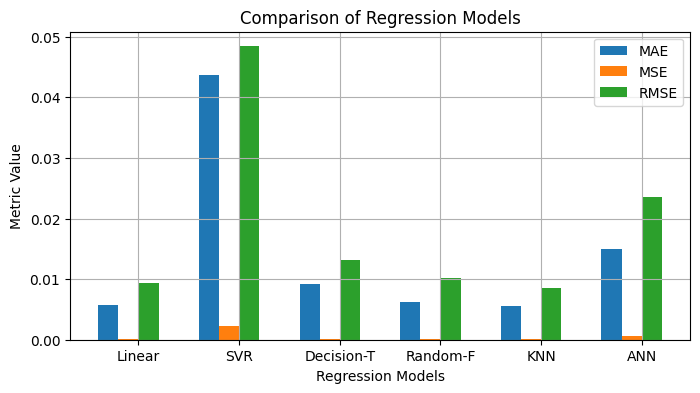

In [49]:
models = results["Model"]
x = np.arange(len(models))
width = 0.2
plt.figure(figsize=(8,4))
plt.bar(x - 1.5*width, results["MAE"], width, label="MAE")
plt.bar(x - 0.5*width, results["MSE"], width, label="MSE")
plt.bar(x + 0.5*width, results["RMSE"], width, label="RMSE")
# plt.bar(x + 1.5*width, results["R2"], width, label="R²")
plt.xticks(x, models)
plt.xlabel("Regression Models")
plt.ylabel("Metric Value")
plt.title("Comparison of Regression Models")
plt.legend()
plt.grid()
plt.show()